# Notebook 4: Quantum elementary cellular automata

https://journals.aps.org/prx/abstract/10.1103/PhysRevX.10.021019?__cf_chl_f_tk=iZTafzML8r8CAw4PPaQuV_Q7m8MfKYS9mbgr9xT6YBA-1783012629-1.0.1.1-N2efWkSyeWKJSMvli0HKFHr1f2MsEo5gQkLfQFbfqKI

Takeaways from the literature review:

1. Set-up:
- The topic is the application of statistics for open (dissipative) quantum systems.
- Extends notion of chaos from hermitian space like standard quantum mechanics to non-hermitian spaces (Lindbladians)
- This has been understood for decades:
- - In closed quantum systems energy eigenvalues are real numbers and a standard way of detetcing quantum chaos is to look at differenc between energy levels.
In integrable systems levels are uncorrelated and follow Poisson statistics. In chaotic systems energy pevels repel each other and follow Rabdom Matrox Theory.
- - Open Quantum systems are a special case: They interact openly with their environment and they don't exist in hermitian sapce, and operartors in this space have complex eigenvalues.
- - How do we measure spectral correlations when eigenvalues are complex?

2. Solution to the problem:
- They define a complex spacing ratio, defined the following way where λ_1 is a given eigenvalue, λ_2 is its nearest eigenvalue and λ_3 is its second nearest eigenvalue and is itself a complex number:

z = (λ_2-λ_1)/(λ_3-λ_1)

- z contains information regarding the magnitude and angle, si it can describe the complex plane.

3. The value of z and the main takeaway from the paper:
- The distribution of these complex ratios can be used to distinguish chaotic from ordered systems
- Integrable systems: Eigenvalues are random points in the complex plane and no orientation is preferred. Complex analogue of Poisson statistics.
- Chaotic systems: Ratios have an angular structure and Random Matrix Theory predictions appear. Angular dependence is an indicator of chaotic behaviour.
- Complex ratios are really easy to compute numerically.
- Examples of Random Matric predictions are looked at (Poisson spectra, Gaussian Unitary Ensemble, and Ginibre Unitary Ensemble). It is shown that very small random matrices (3x3) approcimate the reuslts of huge matrices.

4. Systems they test:
- Lynbladian dynamics (open quantum spin chains with dissipation): Integrable chains have a flat z distribution and chatic chains follow Ginibre statistics.
- Non-hermitian many body hamiltonians
- Classical stochastic systems: They show the behaviour applies beyond quantum mechanics.

5. What it shows:
- This paper discovered there is a simple way to diagnose dissipative quantum chaos.


In [2]:
import numpy as np
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt

[ 0.99140677  0.00859323 -0.00866771]
Distance: [0.87795738 0.56068995 0.43931005 0.78351691] 
 Angle: [0.         0.         0.         3.14159265]


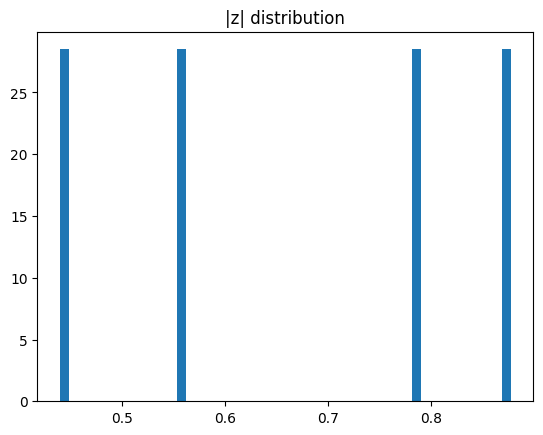

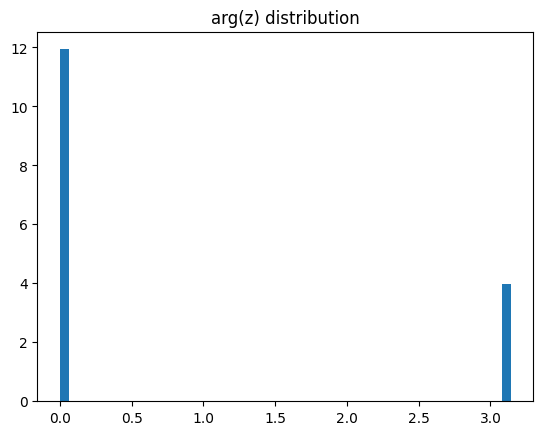

In [3]:
def csr(M): # M is a matrix
    eigenvalues = np.linalg.eigvals(M)
    evals = np.asarray(eigenvalues)

    # Build the 2d complex plane with points
    points = np.column_stack((evals.real, evals.imag))

    tree = cKDTree(points)

    ratios = []

    for i, p in enumerate(points):

        # query 3 nearest neighbors (itself + 2 nearest)
        dist, idx = tree.query(p, k=3)

        # idx[0] is the point itself (distance 0)
        i1, i2, i3 = idx

        lam1 = evals[i1]
        lam2 = evals[i2]
        lam3 = evals[i3]

        # avoid division by zero (rare degeneracy case mentioned in literature)
        denom = (lam3 - lam1)
        if np.abs(denom) < 1e-12:
            continue

        z = (lam2 - lam1) / denom
        ratios.append(z)

    return np.array(ratios)

M = np.array([[1,2,3],
            [3,2,1],
            [22,44,543]])
print(csr(M))

def phase_distribution(M):
    z = csr(M)
    
    
    r = np.abs(z)
    theta = np.angle(z)
    print(f"Distance: {r}", "\n", f"Angle: {theta}")

    plt.hist(r, bins=50, density=True)
    plt.title("|z| distribution")
    plt.show()  

    plt.hist(theta, bins=50, density=True)
    plt.title("arg(z) distribution")
    plt.show()

M = np.array([
    [0.10, 0.20, 0.30, 0.40],
    [0.25, 0.25, 0.25, 0.25],
    [0.50, 0.20, 0.20, 0.10],
    [0.05, 0.15, 0.30, 0.50]])
phase_distribution(M.T)

Distance: [0.93416663 0.60582804 0.99999996 0.99999996 1.         0.81206756
 1.         0.5        0.5        1.        ] 
 Angle: [-0.00000000e+00 -5.28694256e-01 -1.75238781e-08  1.75238781e-08
  1.01909676e-07  0.00000000e+00  5.96328070e-07 -3.57994431e-07
  3.57994431e-07  3.14159194e+00]


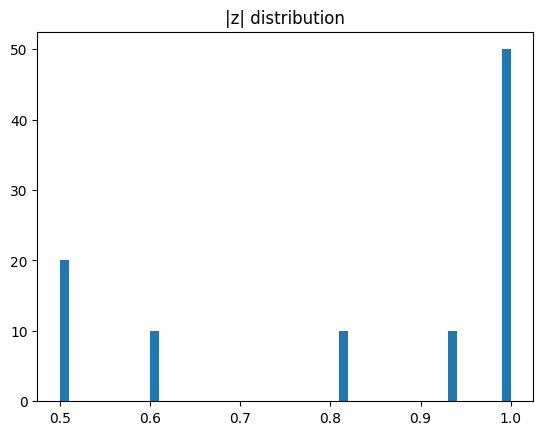

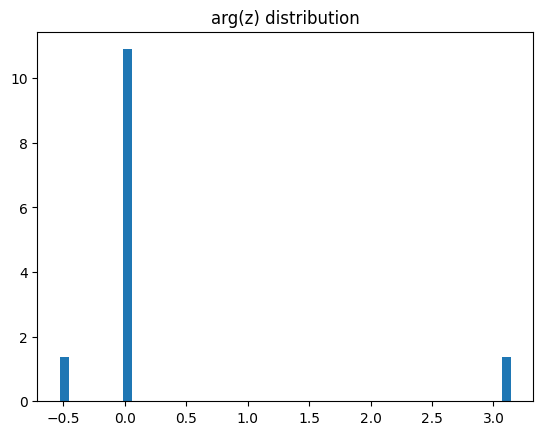

In [4]:


P = np.array([
    [0.05, 0.10, 0.15, 0.05, 0.10, 0.10, 0.10, 0.15, 0.10, 0.20],
    [0.10, 0.05, 0.10, 0.10, 0.10, 0.05, 0.15, 0.10, 0.15, 0.10],
    [0.08, 0.12, 0.05, 0.10, 0.10, 0.10, 0.10, 0.10, 0.15, 0.10],
    [0.10, 0.10, 0.10, 0.05, 0.10, 0.10, 0.10, 0.10, 0.15, 0.10],
    [0.10, 0.10, 0.10, 0.10, 0.05, 0.10, 0.10, 0.10, 0.10, 0.15],
    [0.10, 0.05, 0.10, 0.10, 0.10, 0.10, 0.10, 0.15, 0.10, 0.10],
    [0.10, 0.10, 0.10, 0.10, 0.10, 0.05, 0.10, 0.10, 0.15, 0.10],
    [0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.05, 0.10, 0.10, 0.15],
    [0.15, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.05, 0.10, 0.10],
    [0.10, 0.15, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.05, 0.10]
])

phase_distribution(P)

# Fix the bug on reversed dynamiocs form nitebook 1
# Fix the rrors that arised form this bug

# Updte it on the github

# Continue looking at spectral analysis of the matrices, look at ivese atrices and ñroivide a summary to the propertyof transition matrices
# fina way to plotthe same plot fopm the paper
# plot it for all wolframs classes
# Find a way to classify them if possible
